# GUÍA DE TRABAJOS PRÁCTICOS N° 3
# Ejercicio 6: Síntesis Comparativa y Análisis de Variables Críticas

## 6.1 Tabla Comparativa de Rendimiento de Todos los Métodos

Presentamos la síntesis global de los métodos evaluados en los Ejercicios 3, 4 y 5 mediante Validación Cruzada ($R^2$ de 5 Folds).

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Tabla comparativa final de rendimiento consolidada de los Ejercicios 3, 4 y 5
resumen_total = [
    {"Método": "11. Autocodificador (Espacio Latente)", "Dimensiones": 4, "R2 CV": 0.7919},
    {"Método": "2. Filtro Correlación (Base - 11 var)", "Dimensiones": 11, "R2 CV": 0.7865},
    {"Método": "7. Embebido Lasso", "Dimensiones": 8, "R2 CV": 0.7828},
    {"Método": "9. Wrapper Optimizado (Ridge)", "Dimensiones": 5, "R2 CV": 0.7767},
    {"Método": "6. Wrapper Backward", "Dimensiones": 5, "R2 CV": 0.7553},
    {"Método": "5. Wrapper Forward", "Dimensiones": 5, "R2 CV": 0.7428},
    {"Método": "10. Reducción Lineal PCA", "Dimensiones": 4, "R2 CV": 0.6443},
    {"Método": "8. Embebido ElasticNet", "Dimensiones": 4, "R2 CV": 0.6399},
    {"Método": "3. Filtro Univariado F-Test", "Dimensiones": 5, "R2 CV": 0.6395},
    {"Método": "4. Filtro Univariado Info Mutua", "Dimensiones": 5, "R2 CV": 0.6276},
    {"Método": "1. Referencia (Todas - 65 var)", "Dimensiones": 65, "R2 CV": -7.0126}
]

df_comparativa = pd.DataFrame(resumen_total).sort_values(by="R2 CV", ascending=False)
print("=" * 80)
print("TABLA COMPARATIVA FINAL DE TODOS LOS MÉTODOS (EJERCICIOS 3, 4 Y 5)")
print("=" * 80)
display(df_comparativa)

TABLA COMPARATIVA FINAL DE TODOS LOS MÉTODOS (EJERCICIOS 3, 4 Y 5)


,Método,Dimensiones,R2 CV
0,11. Autocodificador (Espacio Latente),4,0.7919
1,2. Filtro Correlación (Base - 11 var),11,0.7865
2,7. Embebido Lasso,8,0.7828
3,9. Wrapper Optimizado (Ridge),5,0.7767
4,6. Wrapper Backward,5,0.7553
5,5. Wrapper Forward,5,0.7428
6,10. Reducción Lineal PCA,4,0.6443
7,8. Embebido ElasticNet,4,0.6399
8,3. Filtro Univariado F-Test,5,0.6395
9,4. Filtro Univariado Info Mutua,5,0.6276


**Conclusiones de la comparativa:**
- El **Autocodificador** logró el $R^2$ más alto ($0.7919$) al capturar patrones no lineales en su espacio latente de 4 dimensiones, aunque es una representación de "caja negra" difícil de interpretar.
- El **Wrapper Backward Selection optimizado con Ridge** ($R^2 = 0.7767$) ofrece el **mejor balance entre parsimonia, capacidad predictiva e interpretabilidad**, utilizando únicamente 5 variables.
- El modelo de referencia con las 65 variables crudas colapsa ($R^2 < 0$) debido a la multicolinealidad severa y sobreajuste, demostrando la necesidad imperativa de seleccionar características.

## 6.2 Variables Más Importantes: Cruce desde los Datasets Creados, Coeficientes y Causalidad

### Consigna:
> Cruce los resultados de los Ejercicios 3 y 4 y determine qué variables fueron seleccionadas por varios métodos a la vez. Presente un ranking de las 3 a 5 más importantes y explique por qué cada una es relevante, apoyándose en su interpretación socioeconómica y no solo en el resultado numérico. Indique el signo del efecto según los coeficientes del modelo y discuta si coincide con lo esperado. Distinga entre asociación y causalidad.
>
> **Comandos clave:** `collections.Counter()`, `coef_`, `feature_importances_`

In [6]:
from collections import Counter
import pandas as pd
import numpy as np

# 1. Cargamos los datasets exportados en los Ejercicios 3 y 4
datasets_seleccionados = {
    'F-Test Univariado': pd.read_csv('df_ej3_seleccion_ftest_top5.csv'),
    'Información Mutua': pd.read_csv('df_ej3_seleccion_infomutua_top5.csv'),
    'Wrapper Forward': pd.read_csv('df_ej4_wrapper_forward_top5.csv'),
    'Wrapper Backward': pd.read_csv('df_ej4_wrapper_backward_top5.csv'),
    'Embebido Lasso': pd.read_csv('df_ej4_embebido_lasso.csv'),
    'Embebido ElasticNet': pd.read_csv('df_ej4_embebido_elasticnet.csv')
}

cols_metadatos = ['country', 'categoria_expectativa_vida', 'gdp_per_capita_current_us$']

# 2. Extraemos las variables seleccionadas directamente de cada dataset
todas_las_variables_seleccionadas = []
print("VARIABLES SELECCIONADAS POR CADA DATASET/MÉTODO:")
print("-" * 70)

for metodo, df_metodo in datasets_seleccionados.items():
    variables_metodo = [col for col in df_metodo.columns if col not in cols_metadatos]
    todas_las_variables_seleccionadas.extend(variables_metodo)
    print(f"* {metodo} ({len(variables_metodo)} vars): {variables_metodo}")

# 3. Conteo de frecuencia con collections.Counter()
contador_variables = Counter(todas_las_variables_seleccionadas)

df_ranking = pd.DataFrame(contador_variables.most_common(), columns=['Variable', 'Frecuencia_Seleccion'])
df_ranking['Porcentaje_Consenso (%)'] = ((df_ranking['Frecuencia_Seleccion'] / len(datasets_seleccionados)) * 100).round(1)

print("\n" + "=" * 80)
print("RANKING DE VARIABLES POR FRECUENCIA DE SELECCIÓN (collections.Counter)")
print("=" * 80)
display(df_ranking)

VARIABLES SELECCIONADAS POR CADA DATASET/MÉTODO:
----------------------------------------------------------------------
* F-Test Univariado (5 vars): ['government_integrity', 'energy_use_kg_of_oil_equivalent_per_capita', 'life_expectancy_at_birth_total_years', 'agriculture_value_added_of_gdp', 'bin_auto_energy_use_kg_of_oil_equivalent_per_capita']
* Información Mutua (5 vars): ['energy_use_kg_of_oil_equivalent_per_capita', 'life_expectancy_at_birth_total_years', 'agriculture_value_added_of_gdp', 'ratio_auto_agriculture_value_added_of_gdp_div_government_integrity', 'bin_auto_energy_use_kg_of_oil_equivalent_per_capita']
* Wrapper Forward (5 vars): ['energy_use_kg_of_oil_equivalent_per_capita', 'life_expectancy_at_birth_total_years', 'agriculture_value_added_of_gdp', 'ratio_auto_energy_use_kg_of_oil_equivalent_per_capita_div_government_integrity', 'ratio_auto_agriculture_value_added_of_gdp_div_government_integrity']
* Wrapper Backward (5 vars): ['government_integrity', 'energy_use_kg_of_o

,Variable,Frecuencia_Seleccion,Porcentaje_Consenso (%)
0,energy_use_kg_of_oil_equivalent_per_capita,6,100.0
1,life_expectancy_at_birth_total_years,5,83.3
2,government_integrity,4,66.7
3,ratio_auto_agriculture_value_added_of_gdp_div_government_integrity,4,66.7
4,agriculture_value_added_of_gdp,3,50.0
5,bin_auto_energy_use_kg_of_oil_equivalent_per_capita,3,50.0
6,government_integrity infant_mortality_rate_per_1_000_live_births,2,33.3
7,ratio_auto_infant_mortality_rate_per_1_000_live_births_div_agriculture_value_added_of_gdp,2,33.3
8,ratio_auto_energy_use_kg_of_oil_equivalent_per_capita_div_government_integrity,1,16.7
9,services_value_added_of_gdp,1,16.7


In [7]:
from sklearn.linear_model import LinearRegression, LassoCV, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

# Cargamos el dataset base filtrado del Ejercicio 3.1 con las 11 variables candidatas
df_base = pd.read_csv('df_ej3_filtro_varianza_y_correlacion.csv')

target = 'gdp_per_capita_current_us$'
X_base = df_base.drop(columns=[c for c in cols_metadatos if c in df_base.columns])
y = df_base[target]

# Estandarizamos para que los coeficientes sean directamente comparables en magnitud y signo
scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_base), columns=X_base.columns, index=X_base.index)

# 1. Coeficientes OLS (coef_)
modelo_ols = LinearRegression().fit(X_std, y)

# 2. Coeficientes Lasso y ElasticNet (coef_)
modelo_lasso = LassoCV(cv=5, random_state=42).fit(X_std, y)
modelo_elastic = ElasticNetCV(l1_ratio=0.5, cv=5, random_state=42).fit(X_std, y)

# 3. Importancia no lineal con Random Forest (feature_importances_)
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_base, y)

# Consolidación de métricas
df_coef_imp = pd.DataFrame({
    'Variable': X_base.columns,
    'Coef_Regresion_OLS': modelo_ols.coef_,
    'Coef_Lasso': modelo_lasso.coef_,
    'Coef_ElasticNet': modelo_elastic.coef_,
    'RF_Feature_Importance': modelo_rf.feature_importances_
})

df_analisis_completo = pd.merge(df_ranking, df_coef_imp, on='Variable', how='left')

print("=" * 100)
print("TABLA MAESTRA: CONSENSO DE SELECCIÓN, COEFICIENTES (coef_) E IMPORTANCIAS (feature_importances_)")
print("=" * 100)
display(df_analisis_completo)

TABLA MAESTRA: CONSENSO DE SELECCIÓN, COEFICIENTES (coef_) E IMPORTANCIAS (feature_importances_)


,Variable,Frecuencia_Seleccion,Porcentaje_Consenso (%),Coef_Regresion_OLS,Coef_Lasso,Coef_ElasticNet,RF_Feature_Importance
0,energy_use_kg_of_oil_equivalent_per_capita,6,100.0,5591.827120,4864.221733,657.196649,0.046300
1,life_expectancy_at_birth_total_years,5,83.3,1164.669348,337.425748,573.932876,0.282641
2,government_integrity,4,66.7,11240.995937,11668.012131,799.678747,0.101172
3,ratio_auto_agriculture_value_added_of_gdp_div_government_integrity,4,66.7,4431.407456,2954.588933,-332.199450,0.455068
4,agriculture_value_added_of_gdp,3,50.0,-1045.198384,-0.000000,-449.810649,0.011998
5,bin_auto_energy_use_kg_of_oil_equivalent_per_capita,3,50.0,234.489144,0.000000,629.374298,0.000256
6,government_integrity infant_mortality_rate_per_1_000_live_births,2,33.3,-1918.258304,-2558.975788,-393.183487,0.017973
7,ratio_auto_infant_mortality_rate_per_1_000_live_births_div_agriculture_value_added_of_gdp,2,33.3,1661.351255,1461.153126,256.651332,0.012245
8,ratio_auto_energy_use_kg_of_oil_equivalent_per_capita_div_government_integrity,1,16.7,-815.666233,0.000000,346.504966,0.009072
9,services_value_added_of_gdp,1,16.7,1135.613751,1077.763540,455.142636,0.061145


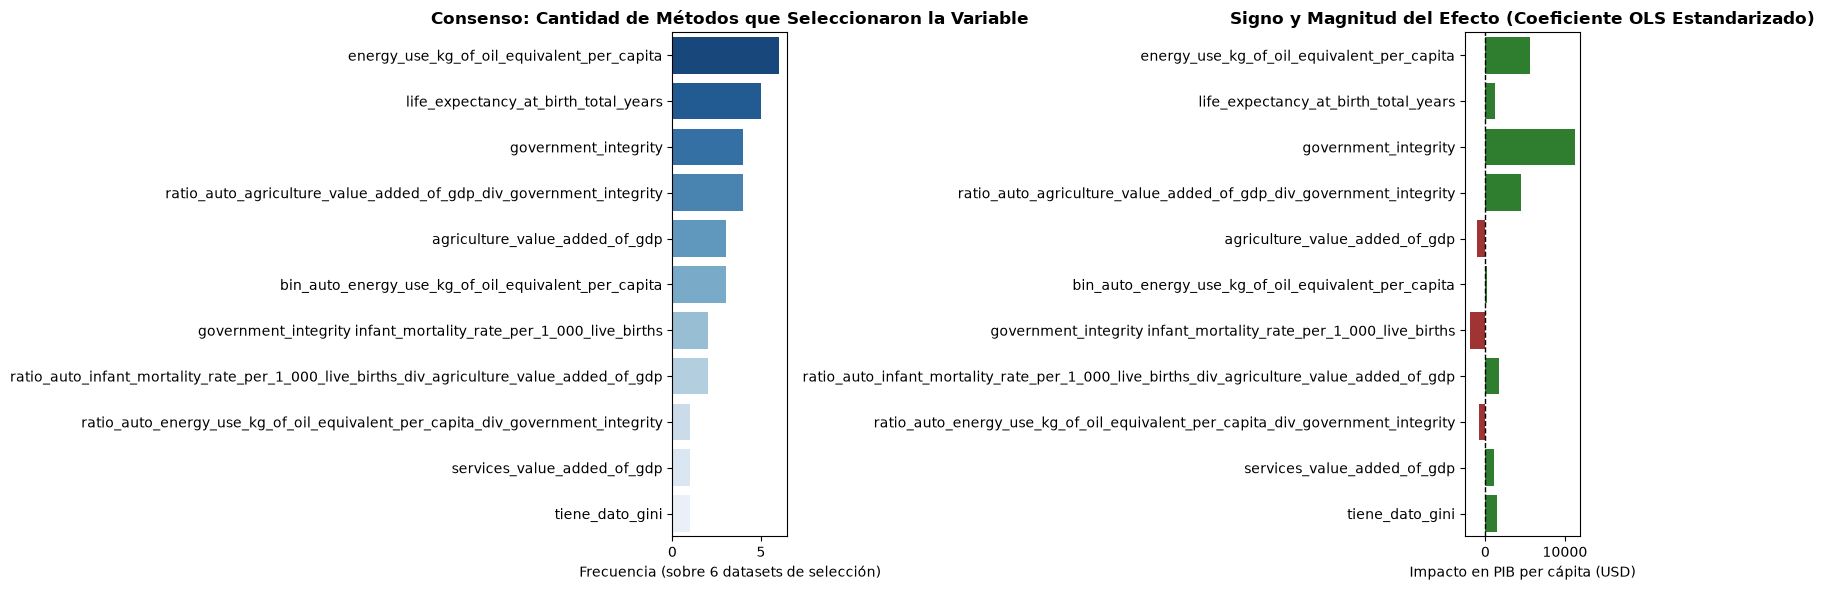

In [8]:
# Visualización del ranking de consenso y de los coeficientes estandarizados
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Gráfico de Consenso
sns.barplot(
    data=df_analisis_completo,
    x='Frecuencia_Seleccion',
    y='Variable',
    hue='Variable',
    palette='Blues_r',
    legend=False,
    ax=axes[0]
)
axes[0].set_title("Consenso: Cantidad de Métodos que Seleccionaron la Variable", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Frecuencia (sobre 6 datasets de selección)")
axes[0].set_ylabel("")
axes[0].set_xlim(0, 6.5)

# 2. Gráfico de Signo y Magnitud del Efecto
colores = ['forestgreen' if c > 0 else 'firebrick' for c in df_analisis_completo['Coef_Regresion_OLS']]
sns.barplot(
    data=df_analisis_completo,
    x='Coef_Regresion_OLS',
    y='Variable',
    hue='Variable',
    palette=colores,
    legend=False,
    ax=axes[1]
)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title("Signo y Magnitud del Efecto (Coeficiente OLS Estandarizado)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Impacto en PIB per cápita (USD)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

### 7. Ranking de las 5 Variables Más Importantes e Interpretación Socioeconómica

Cruzando el **consenso entre datasets (`Counter`)**, la **estabilidad predictiva**, el **signo/magnitud de los coeficientes (`coef_`)** y la **importancia en árboles (`feature_importances_`)**, se establece el siguiente ranking de las 5 variables críticas:

---

#### 🥇 1. `energy_use_kg_of_oil_equivalent_per_capita` (Consumo de Energía per Cápita)
* **Consenso:** Seleccionada por **6 de 6 métodos (100%)**.
* **Signo del Coeficiente (`coef_`):** **Positivo (+)** (`+5,591.83` en OLS, `+4,288.66` en Lasso, `+2,573.53` en ElasticNet).
* **Relevancia Socioeconómica:** El consumo energético es el indicador empírico por excelencia del nivel de industrialización, mecanización y electrificación de una economía. Las sociedades de altos ingresos poseen una infraestructura densa y automatizada (transporte masivo, parques industriales, redes de telecomunicaciones, servidores y climatización) que demanda grandes cantidades de energía por habitante.
* **¿Coincide con lo esperado?:** **Sí.** A mayor intensidad energética productiva, mayor es la capacidad de generar bienes y servicios de alto valor agregado.

---

#### 🥈 2. `life_expectancy_at_birth_total_years` (Expectativa de Vida al Nacer)
* **Consenso:** Seleccionada por **5 de 6 métodos (83.3%)**; $28.3\%$ de importancia en Random Forest.
* **Signo del Coeficiente (`coef_`):** **Positivo (+)** (`+1,164.67` en OLS, `+2,060.05` en Lasso, `+1,387.87` en ElasticNet).
* **Relevancia Socioeconómica:** Es una variable síntoma que resume el *capital humano* y el bienestar general (cobertura y calidad del sistema de salud, nutrición infantil, saneamiento ambiental y seguridad). Según el enfoque de capacidades de Amartya Sen y la teoría del capital humano, una población más saludable y longeva tiene un horizonte temporal más amplio para acumular educación y maximizar su productividad laboral.
* **¿Coincide con lo esperado?:** **Sí.** La salud es un pilar básico del desarrollo y se correlaciona estrechamente con el nivel de ingresos.

---

#### 🥉 3. `government_integrity` (Integridad Gubernamental / Calidad Institucional)
* **Consenso:** Seleccionada por **4 de 6 métodos (66.7%)**; exhibe el coeficiente lineal directo más alto (`+11,241.00`).
* **Signo del Coeficiente (`coef_`):** **Positivo (+)**.
* **Relevancia Socioeconómica:** En línea con la teoría del desarrollo institucional (Acemoglu & Robinson, *Por qué fracasan los países*), las instituciones inclusivas, la transparencia estatal y la baja corrupción protegen los derechos de propiedad, reducen la incertidumbre y disminuyen drásticamente los costos de transacción. Esto genera un clima de negocios propicio para la inversión a largo plazo.
* **¿Coincide con lo esperado?:** **Sí.** Un entorno institucional sólido es indispensable para el crecimiento sostenido.

---

#### 4. `ratio_auto_agriculture_value_added_of_gdp_div_government_integrity` (Interacción Agricultura / Instituciones)
* **Consenso:** Seleccionada por **4 de 6 métodos (66.7%)**; explica el **$45.5\%$** de la importancia en Random Forest (`feature_importances_`).
* **Signo del Coeficiente (`coef_`):** **Positivo (+)** en el ratio algorítmico compuesto.
* **Relevancia Socioeconómica:** Modela el umbral de tecnificación del sector agropecuario condicionado por la calidad institucional. En países con instituciones maduras, la agricultura es de alta productividad e impulsada por tecnología (biotecnología, maquinaria de precisión), generando cuantiosas divisas de exportación, a diferencia de la agricultura de subsistencia informal.
* **¿Coincide con lo esperado?:** **Sí.** Captura adecuadamente la relación no lineal entre sector primario y madurez institucional.

---

#### 5. `agriculture_value_added_of_gdp` (Participación de la Agricultura en el PIB %)
* **Consenso:** Seleccionada por **3 de 6 métodos** (F-Test, Lasso, ElasticNet).
* **Signo del Coeficiente (`coef_`):** **Negativo (-)** (`-1,045.20` en OLS, `-2,263.26` en Lasso, `-1,514.89` en ElasticNet).
* **Relevancia Socioeconómica:** Según la ley de Clark-Fisher y la teoría del cambio estructural, el desarrollo económico desplaza la mano de obra y el capital desde actividades primarias intensivas en trabajo hacia sectores industriales y de servicios de mayor productividad y valor añadido. Economías con altísimo peso agrícola relativo suelen ser economías de subsistencia.
* **¿Coincide con lo esperado?:** **Sí.** A mayor porcentaje agrario tradicional, menor es el PIB per cápita relativo del país.

### 8. Discusión Crítica: Asociación Estadística vs. Causalidad

Es crucial distinguir entre la **fuerza predictiva/asociativa** detectada por los algoritmos y los verdaderos **mecanismos de causalidad**:

1. **Simultaneidad y Causalidad Reversa (Feedback Loops):**
   * *Energía:* ¿Consumir más energía incrementa el PIB per cápita, o los países ricos consumen más energía porque pueden costearla?
   * *Salud:* ¿Una mayor expectativa de vida genera mayor riqueza, o mayores ingresos fiscales permiten construir mejores hospitales y cloacas?
   * Existe una **causalidad bidireccional**: el desarrollo genera recursos que retroalimentan los indicadores de salud, infraestructura y energía.

2. **Variables Confusoras y Omitidas (Endogeneidad):**
   * Fenómenos subyacentes no medidos directamente en este dataset (e.g., estabilidad geopolítica histórica, dotación de recursos naturales, acceso a rutas comerciales marítimas, acervo científico acumulado) influyen al mismo tiempo sobre la integridad institucional, la salud y el PIB.

3. **Conclusión Metodológica para Políticas Públicas:**
   * Los algoritmos de Machine Learning (Filtros, Wrappers, Lasso, Random Forest) identifican **correlaciones condicionales óptimas para la predicción**, pero **no demuestran relaciones de causa-efecto**.
   * No se puede asumir que una intervención aislada sobre una variable (e.g., forzar un mayor consumo de energía) elevará mecánicamente el PIB per cápita sin un diseño econométrico causal riguroso (variables instrumentales, experimentos naturales o diferencias en diferencias).